
This notebook extracts physiological features from continuous PPG and EDA
signals sampled at 256 Hz (CLAS full_gsr_ppg files). Features are computed
using sliding windows and aggregated to 1 Hz to represent second-by-second
physiological states, following the methodology proposed by Tervonen et al

In [1]:
import numpy as np
import pandas as pd
import neurokit2 as nk
from pathlib import Path
from tqdm import tqdm
import time


In [2]:
FS = 256                     # Sampling frequency (Hz)
WINDOW_SEC = 30              # Sliding window length (seconds)
WINDOW_SAMPLES = FS * WINDOW_SEC
STEP_SEC = 1                 # Step size for 1 Hz output


In [4]:
import warnings
warnings.filterwarnings("ignore")


In [ ]:
def extract_features_from_full_gsr_ppg(df, participant_id):

    # -------------------------
    # Convert signals
    # -------------------------
    ppg = pd.to_numeric(df["ppg"], errors="coerce")
    eda = pd.to_numeric(df["gsr"], errors="coerce")

    ppg = ppg.interpolate().bfill().ffill()
    eda = eda.interpolate().bfill().ffill()

    # -------------------------
    # Process signals
    # -------------------------
    signals_ppg, info_ppg = nk.ppg_process(ppg, sampling_rate=FS)
    signals_eda, _ = nk.eda_process(eda, sampling_rate=FS)

    # -------------------------
    # RR intervals (IBI )
    # -------------------------
    rpeaks = info_ppg["PPG_Peaks"]
    rr_intervals = np.diff(rpeaks) / FS * 1000
    rr_times = rpeaks[1:]

    features = []
    step_samples = FS * STEP_SEC

    for start in range(0, len(df) - WINDOW_SAMPLES, step_samples):

        end = start + WINDOW_SAMPLES
        window = {}

        # HR
        hr_window = signals_ppg["PPG_Rate"].iloc[start:end]
        window["HR"] = hr_window.mean(skipna=True)

        # HRV
        rr_mask = (rr_times >= start) & (rr_times < end)
        rr_win = rr_intervals[rr_mask]

        if len(rr_win) >= 5:
            diff_rr = np.diff(rr_win)
            window["HRV_RMSSD"] = np.sqrt(np.mean(diff_rr ** 2))
            window["HRV_SDNN"] = np.std(rr_win, ddof=1)
        else:
            window["HRV_RMSSD"] = np.nan
            window["HRV_SDNN"] = np.nan

        # EDA
        eda_window = signals_eda.iloc[start:end]

        window["EDA_Tonic"] = eda_window["EDA_Tonic"].mean()
        window["EDA_Phasic"] = eda_window["EDA_Phasic"].mean()
        window["SCR_Count"] = int(eda_window["SCR_Peaks"].sum())

        # Metadata
        window["participant"] = participant_id
        window["time_sec"] = start // FS

        features.append(window)

    return pd.DataFrame(features)

In [ ]:
DATA_DIR = Path("../data/raw/Participants")

# -------------------------
# Collect participant files
# -------------------------
participant_files = sorted(
    DATA_DIR.rglob("full_gsr_ppg*.csv"),
    key=lambda x: int(x.parent.name.replace("Part", ""))
)
print("Found files:", len(participant_files))
for f in participant_files[:5]:
    print(f)
# -------------------------
# Select participants 1–42
# -------------------------
participant_files = participant_files[:42]

all_features = []

start_time = time.time()

for i, file in enumerate(tqdm(participant_files, desc="Processing participants")):
    participant_id = file.parent.name

    print(f"\nProcessing {participant_id} ({i+1}/{len(participant_files)})")

    df = pd.read_csv(file)

    participant_features = extract_features_from_full_gsr_ppg(
        df, participant_id
    )

    all_features.append(participant_features)

    # -------------------------
    # Time estimation
    # -------------------------
    elapsed = time.time() - start_time
    avg_time = elapsed / (i + 1)
    remaining = avg_time * (len(participant_files) - (i + 1))

    print(
        f"Elapsed: {elapsed/60:.1f} min | "
        f"Remaining: {remaining/60:.1f} min"
    )


In [14]:
import os
print(os.getcwd())


c:\Users\pat19\OneDrive\Skrivbord\Thesis\CLAS_SOM_project\notebooks


In [ ]:
for f in participant_files:
    print(f)

In [ ]:
features_df = pd.concat(all_features, ignore_index=True)


In [ ]:
features_df = features_df.dropna().reset_index(drop=True)


In [ ]:
features_df.describe()


,HR,HRV_RMSSD,HRV_SDNN,SCR_Count,time_sec,EDA_Tonic_log,EDA_Phasic_log
count,94640.000000,94640.000000,94640.000000,94640.000000,94640.000000,94640.000000,94640.000000
mean,80.066498,69.745746,63.423947,0.936898,1130.342794,6.938545,-2.126226
std,11.241744,45.706323,33.005219,1.238159,656.249307,0.607125,1.642081
min,52.598237,7.850703,10.166059,0.000000,0.000000,-5.000000,-5.000000
25%,71.929622,35.730268,40.118531,0.000000,563.000000,6.661611,-3.192672
50%,79.242658,54.994327,55.899645,0.000000,1126.000000,6.756966,-2.138944
75%,87.493492,92.216511,77.650820,2.000000,1695.000000,6.900997,-1.186191
max,141.217339,200.000000,200.000000,13.000000,2309.000000,10.000000,5.000000


In [ ]:
# -------------------------
# EDA stabilization
# -------------------------
EPS = 1e-6

features_df["EDA_Tonic_log"] = np.log(features_df["EDA_Tonic"] - features_df["EDA_Tonic"].min() + EPS)
features_df["EDA_Phasic_log"] = np.log(np.abs(features_df["EDA_Phasic"]) + EPS)

# Drop raw EDA
features_df = features_df.drop(columns=["EDA_Tonic", "EDA_Phasic"])


In [ ]:
features_df["HRV_RMSSD"] = features_df["HRV_RMSSD"].clip(0,200)
features_df["HRV_SDNN"] = features_df["HRV_SDNN"].clip(0,200)
features_df["EDA_Tonic_log"] = features_df["EDA_Tonic_log"].clip(-5,10)
features_df["EDA_Phasic_log"] = features_df["EDA_Phasic_log"].clip(-5,5)

In [27]:
# Feature columns used for SOM
FEATURE_COLS = [
    "HR",
    "HRV_RMSSD",
    "HRV_SDNN",
    "SCR_Count",
    "EDA_Tonic_log",
    "EDA_Phasic_log"
]

# SOM input matrix
X_features = features_df[FEATURE_COLS]

# (Optional) metadata kept separately
metadata = features_df[["participant", "time_sec"]]


In [31]:
X_features.to_csv(    
    "../data/features_SOM_train_fulltest.csv",
    index=False
)


In [ ]:
features_df.describe()
features_df.shape


,HR,HRV_RMSSD,HRV_SDNN,SCR_Count,time_sec,EDA_Tonic_log,EDA_Phasic_log
count,94640.000000,94640.000000,94640.000000,94640.000000,94640.000000,94640.000000,94640.000000
mean,80.066498,69.745746,63.423947,0.936898,1130.342794,6.938545,-2.126226
std,11.241744,45.706323,33.005219,1.238159,656.249307,0.607125,1.642081
min,52.598237,7.850703,10.166059,0.000000,0.000000,-5.000000,-5.000000
25%,71.929622,35.730268,40.118531,0.000000,563.000000,6.661611,-3.192672
50%,79.242658,54.994327,55.899645,0.000000,1126.000000,6.756966,-2.138944
75%,87.493492,92.216511,77.650820,2.000000,1695.000000,6.900997,-1.186191
max,141.217339,200.000000,200.000000,13.000000,2309.000000,10.000000,5.000000


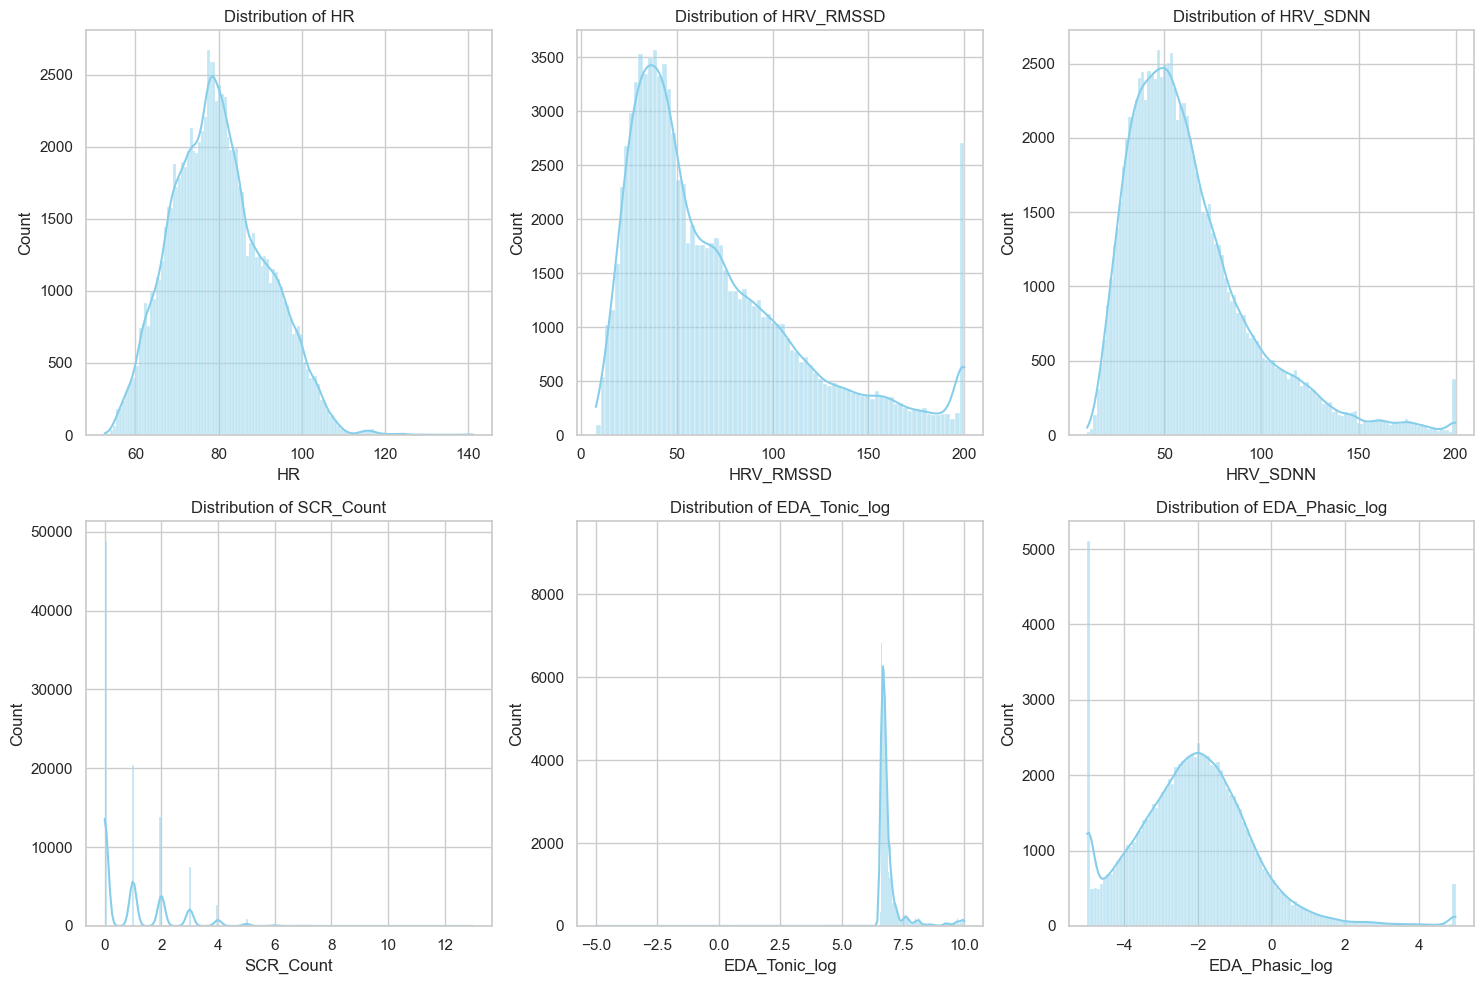

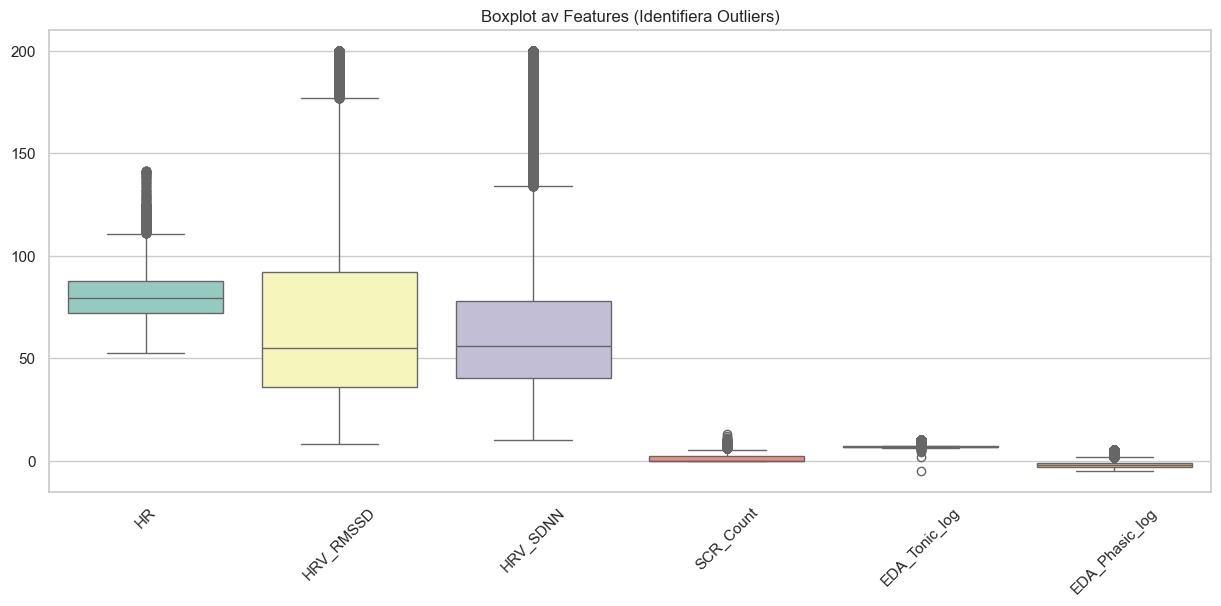

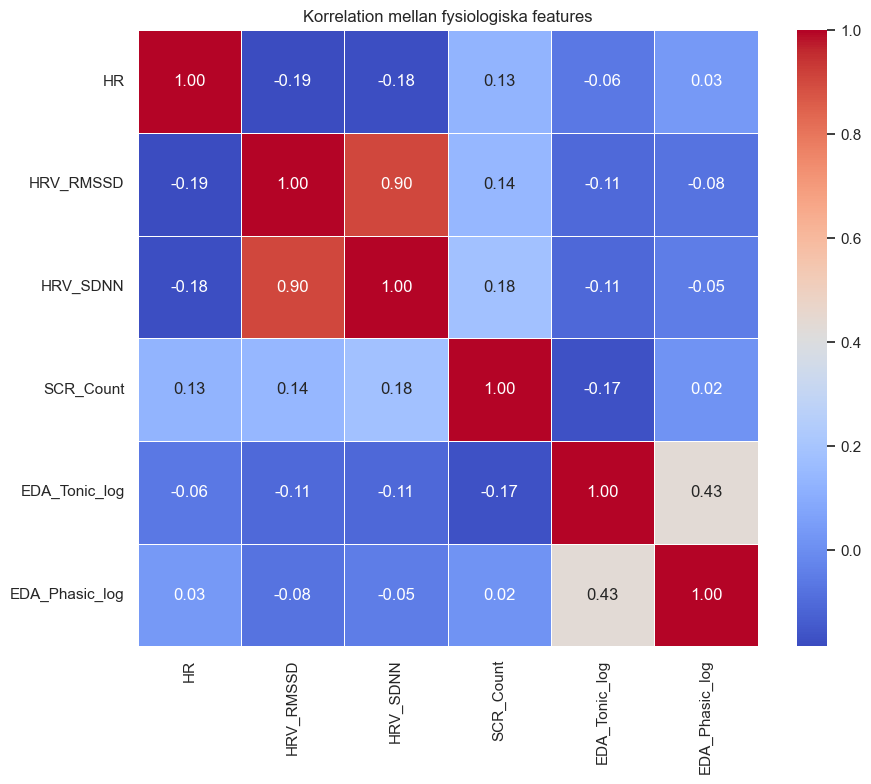

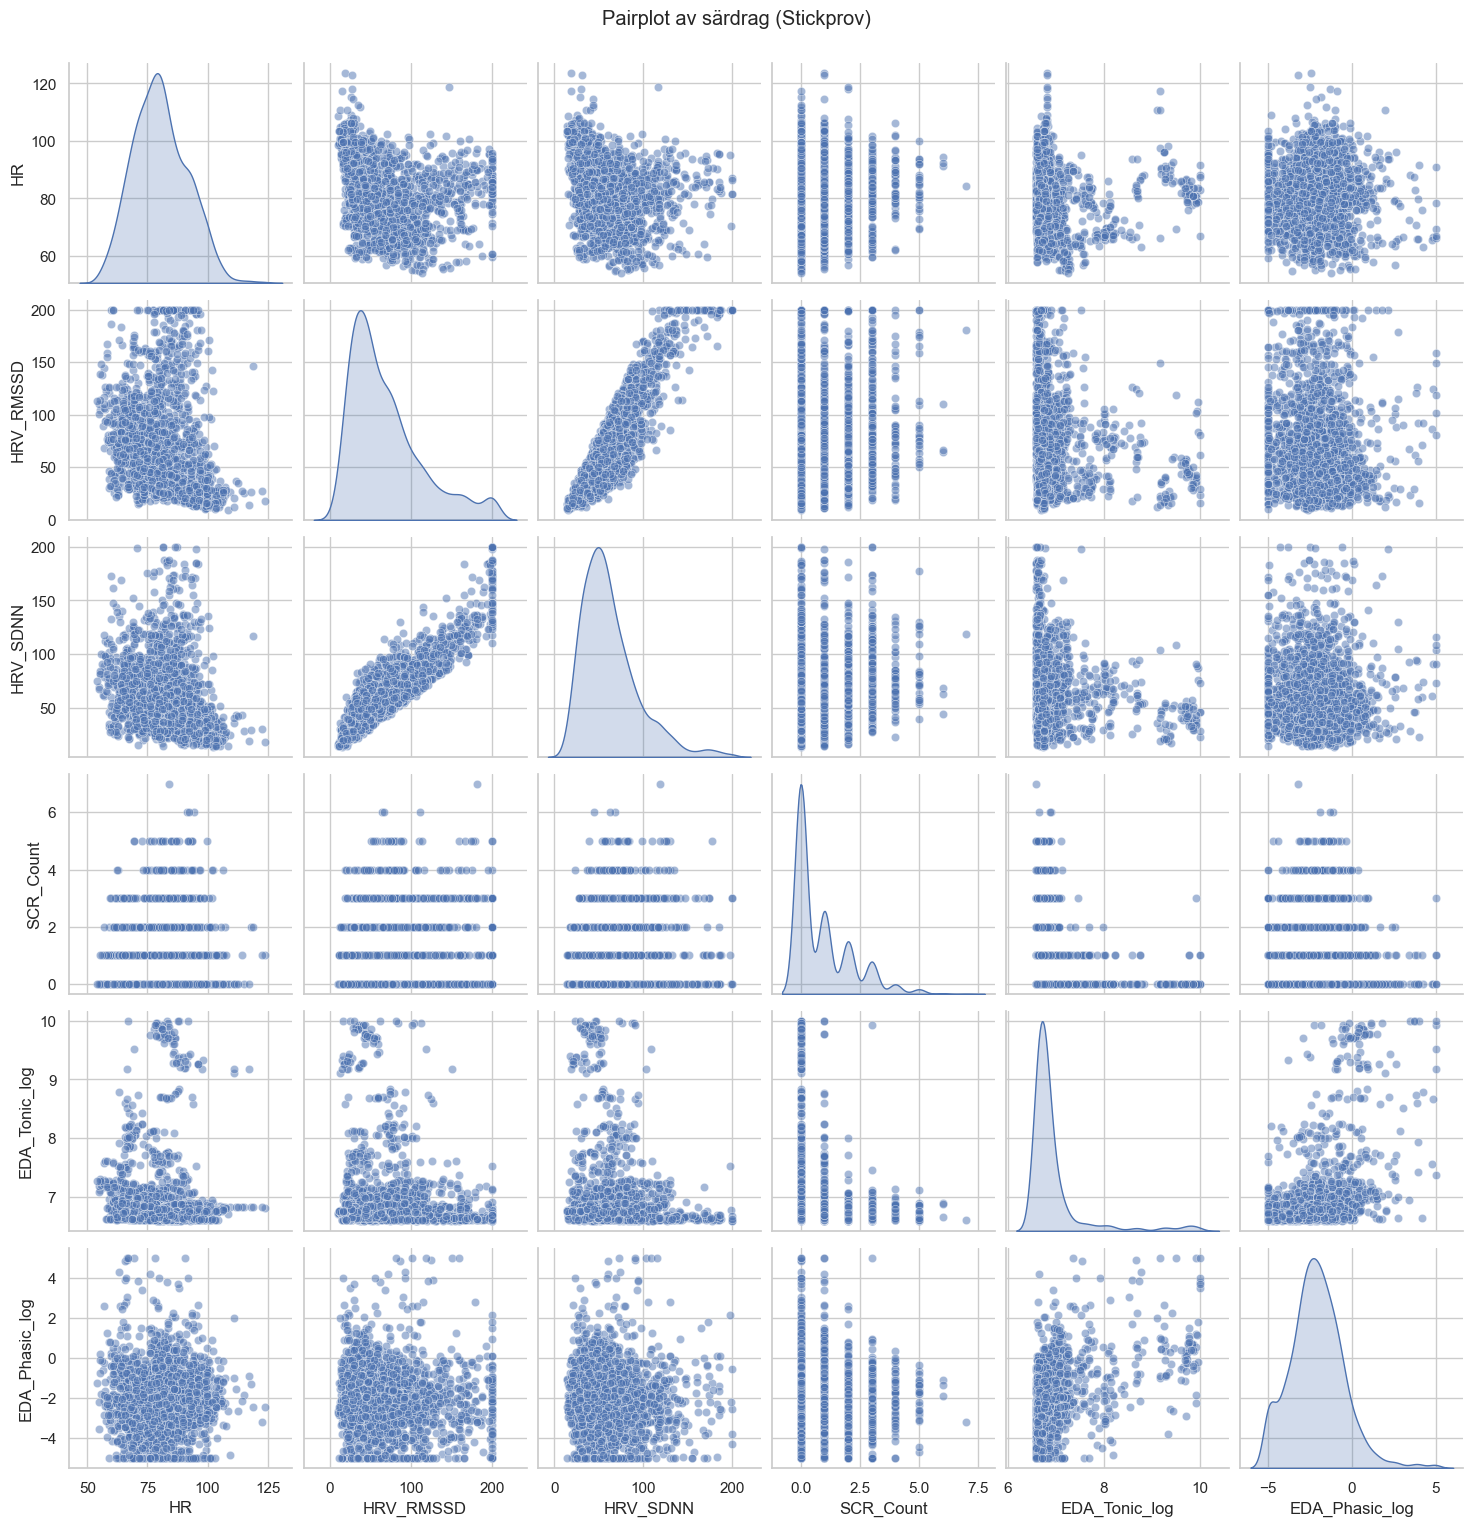

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ställ in stil
sns.set(style="whitegrid")
cols_to_plot = ['HR', 'HRV_RMSSD', 'HRV_SDNN', 'SCR_Count', 'EDA_Tonic_log', 'EDA_Phasic_log']

### 1. Fördelning (Histograms & KDE)
# Hjälper oss se om data är normalfördelad eller skev
plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(features_df[col], kde=True, color="skyblue")
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### 2. Boxplots (Outlier-detektion)
# Viktigt för SOM eftersom den är känslig för extrema avstånd
plt.figure(figsize=(15, 6))
sns.boxplot(data=features_df[cols_to_plot], palette="Set3")
plt.xticks(rotation=45)
plt.title('Boxplot av Features (Identifiera Outliers)')
plt.show()

### 3. Korrelationsmatris (Heatmap)
# Visar om vissa features är redundanta (t.ex. RMSSD vs SDNN)
plt.figure(figsize=(10, 8))
corr = features_df[cols_to_plot].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Korrelation mellan fysiologiska features')
plt.show()

### 4. Pairplot (Relationer mellan variabler)
# Tar en stund att köra men visar kluster-tendenser direkt
# Vi samplar 2000 rader för att det ska gå snabbt
sns.pairplot(features_df[cols_to_plot].sample(2000), diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot av särdrag (Stickprov)', y=1.02)
plt.show()

In [7]:
from pathlib import Path

# -------------------------
# Paths
# -------------------------
DATA_DIR = Path("../data/raw/Participants")
SAVE_PATH = Path("../data/test_part_43.csv")

participant_id = "Part43"

# -------------------------
# Load participant file
# -------------------------
file = list(DATA_DIR.rglob(f"{participant_id}/full_gsr_ppg*.csv"))[0]
df = pd.read_csv(file)

print("Loaded:", file)

# -------------------------
# Feature extraction
# -------------------------
features_df = extract_features_from_full_gsr_ppg(
    df,
    participant_id
)

# -------------------------
# SAME cleaning as train
# -------------------------
features_df = features_df.dropna().reset_index(drop=True)

# -------------------------
# EDA stabilization (same as train)
# -------------------------
EPS = 1e-6

features_df["EDA_Tonic_log"] = np.log(
    features_df["EDA_Tonic"] - features_df["EDA_Tonic"].min() + EPS
)

features_df["EDA_Phasic_log"] = np.log(
    np.abs(features_df["EDA_Phasic"]) + EPS
)

# Drop raw EDA
features_df = features_df.drop(columns=["EDA_Tonic", "EDA_Phasic"])

# -------------------------
# SAME clipping as train
# -------------------------
features_df["HRV_RMSSD"] = features_df["HRV_RMSSD"].clip(0, 200)
features_df["HRV_SDNN"] = features_df["HRV_SDNN"].clip(0, 200)
features_df["EDA_Tonic_log"] = features_df["EDA_Tonic_log"].clip(-5, 10)
features_df["EDA_Phasic_log"] = features_df["EDA_Phasic_log"].clip(-5, 5)

# -------------------------
# SAME features used by SOM
# -------------------------
FEATURE_COLS = [
    "HR",
    "HRV_RMSSD",
    "HRV_SDNN",
    "SCR_Count",
    "EDA_Tonic_log",
    "EDA_Phasic_log"
]

X_test = features_df[FEATURE_COLS]

print("Feature matrix shape:", X_test.shape)

# -------------------------
# Save to CSV
# -------------------------
X_test.to_csv(SAVE_PATH, index=False)

print("Saved test features to:", SAVE_PATH)

Loaded: ..\data\raw\Participants\Part43\full_gsr_ppg.csv
Feature matrix shape: (2300, 6)
Saved test features to: ..\data\test_part_43.csv
